In [24]:
!pip install -q PyPortfolioOpt

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting

In [26]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.443146,170.404495,41.931019,54.717327,76.912796,64.291077,540.298645,102.615837,341.583557,75.843277,...,154.084122,147.359787,392.184113,29.220692,453.210449,399.926666,230.069717,46.069378,45.858700,55.607395
2022-01-04,176.178406,167.522003,43.574490,55.142235,77.167381,67.079926,537.934021,104.482994,343.629242,79.329277,...,154.306793,147.875412,387.097260,30.639349,453.058594,383.196655,229.634125,47.903797,45.018566,57.699009
2022-01-05,171.492096,164.356995,42.839001,54.500546,77.485611,65.929527,524.291016,105.162743,340.098328,77.873299,...,154.832352,148.544830,375.205231,30.639349,444.358917,362.706665,224.653427,47.486069,45.627270,58.416630
2022-01-06,168.629288,163.253998,43.701591,56.286877,76.976433,68.404617,524.176575,106.057594,338.510345,79.470711,...,154.867996,147.296463,374.941589,31.367102,443.941467,354.899994,224.596619,48.702950,45.500458,59.790646
2022-01-07,168.795959,162.554001,44.654984,57.041309,76.776413,70.278351,511.191376,107.580559,338.435638,81.667137,...,155.063965,147.215042,370.879913,32.269890,442.186340,342.320007,223.573944,49.738224,45.934784,60.280720


In [59]:
ef = EfficientFrontier(mu, Sigma)  # new instance
weights = ef.max_sharpe(risk_free_rate=0.02)
cleaned_weights = ef.clean_weights()
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in cleaned_weights.items() if weight > 0],
    columns=["Stock", "Non-Zero Weight"]
)

print(weights_df)

print()

ef.portfolio_performance(verbose=True, risk_free_rate=0.02)


  Stock  Non-Zero Weight
0   MPC          0.14930
1  NVDA          0.19832
2   WMT          0.50386
3   XOM          0.14852

Expected annual return: 33.9%
Annual volatility: 19.1%
Sharpe Ratio: 1.66


(0.33855502198541937, 0.19149192957017006, 1.6635428067410458)

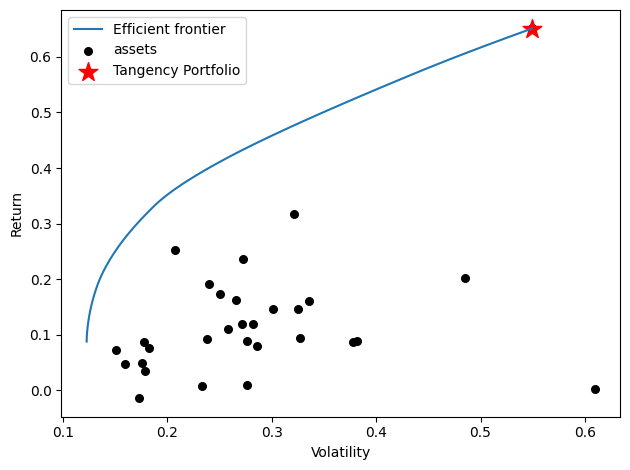

In [65]:
ef = EfficientFrontier(mu, Sigma) 

plotting.plot_efficient_frontier(ef, show_assets=True)

# Mark the tangency portfolio
sharpe_perf = ef.portfolio_performance(verbose=False, risk_free_rate=0.02)
plt.scatter(sharpe_perf[1], sharpe_perf[0], marker="*", color="r", s=200, label="Tangency Portfolio")
plt.legend()
plt.show()
